# Power Drop Investigation: 2026-06-30 Tuesday Easy Run

This notebook investigates the suspicious power drop between **48:00 and 1:18:00**.

Goals:
- Quantify how much power changed in that window versus before/after.
- Check whether the drop is caused by stoppage, pacing, terrain, or sensor artifacts.
- Produce a practical diagnosis for future runs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/activities/easy/processed/2026-06-30_tuesday_easy/record.csv')

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp').reset_index(drop=True)
df['elapsed_s'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()

numeric_cols = [
    'power', 'heart_rate', 'cadence', 'speed', 'distance', 'altitude',
    'step_length', 'stance_time', 'vertical_oscillation', 'vertical_ratio', 'temperature'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['pace_min_per_km'] = 1000 / (df['speed'].replace(0, np.nan) * 60)
df['grade_pct_raw'] = (df['altitude'].diff() / df['distance'].diff().replace(0, np.nan)) * 100
df['grade_pct_30s'] = df['grade_pct_raw'].rolling(30, min_periods=10).mean().clip(-10, 10)

print(f'Rows: {len(df):,}')
print(f'Start: {df["timestamp"].iloc[0]}')
print(f'End:   {df["timestamp"].iloc[-1]}')

Rows: 5,403
Start: 2026-06-29 23:48:09+00:00
End:   2026-06-30 01:18:11+00:00


In [2]:
# Define windows
w0, w1 = 48 * 60, 78 * 60
win = df[(df['elapsed_s'] >= w0) & (df['elapsed_s'] <= w1)].copy()
pre = df[(df['elapsed_s'] >= 18 * 60) & (df['elapsed_s'] < w0)].copy()
post = df[(df['elapsed_s'] > w1) & (df['elapsed_s'] <= 108 * 60)].copy()

# Data-quality and stoppage checks
sensor_sanity = {
    'power_zero_moving': int(((df['power'] <= 0) & (df['speed'] > 1.5)).sum()),
    'cadence_zero_moving': int(((df['cadence'] <= 0) & (df['speed'] > 1.5)).sum()),
    'distance_nonmonotonic_count': int((df['distance'].diff() < 0).sum()),
}

win['is_pause_like'] = (win['speed'] < 0.8) | (win['cadence'] < 120)

metrics = ['power', 'heart_rate', 'cadence', 'speed', 'pace_min_per_km', 'step_length', 'stance_time', 'vertical_ratio', 'grade_pct_30s']

def summarize(x):
    out = {}
    for m in metrics:
        s = x[m].dropna()
        out[m] = {
            'mean': float(s.mean()),
            'median': float(s.median()),
            'p10': float(s.quantile(0.10)),
            'p90': float(s.quantile(0.90)),
        }
    return pd.DataFrame(out).T

summary_pre = summarize(pre)
summary_win = summarize(win)
summary_post = summarize(post)

compare = pd.DataFrame({
    'pre_mean': summary_pre['mean'],
    'window_mean': summary_win['mean'],
    'post_mean': summary_post['mean'],
})
compare['window_vs_pre_%'] = (compare['window_mean'] / compare['pre_mean'] - 1) * 100
compare['window_vs_post_%'] = (compare['window_mean'] / compare['post_mean'] - 1) * 100

print('Sensor sanity:', sensor_sanity)
print('Pause-like points in suspicious window:', int(win['is_pause_like'].sum()))
display(compare.round(3))

Sensor sanity: {'power_zero_moving': 9, 'cadence_zero_moving': 12, 'distance_nonmonotonic_count': 0}
Pause-like points in suspicious window: 0


,pre_mean,window_mean,post_mean,window_vs_pre_%,window_vs_post_%
power,249.699,231.696,249.201,-7.210,-7.024
heart_rate,142.817,146.650,150.325,2.683,-2.445
cadence,165.908,164.941,163.632,-0.583,0.800
speed,2.255,2.256,2.282,0.060,-1.123
pace_min_per_km,7.401,7.391,7.316,-0.133,1.026
step_length,810.448,818.347,832.276,0.975,-1.674
stance_time,283.013,285.165,285.985,0.760,-0.287
vertical_ratio,9.853,9.887,9.856,0.341,0.317
grade_pct_30s,0.013,-0.068,0.007,-641.897,-1023.425


In [3]:
# In-window trend (10-minute bins)
bins = win.copy()
bins['bin_10m'] = ((bins['elapsed_s'] - w0) // 600).astype(int)
bin_table = bins.groupby('bin_10m').agg(
    n=('power', 'size'),
    power=('power', 'mean'),
    hr=('heart_rate', 'mean'),
    cadence=('cadence', 'mean'),
    speed=('speed', 'mean'),
    pace=('pace_min_per_km', 'mean'),
    step=('step_length', 'mean'),
    stance=('stance_time', 'mean'),
    vr=('vertical_ratio', 'mean'),
    grade=('grade_pct_30s', 'mean'),
).reset_index()
display(bin_table.round(3))

corr_cols = ['power', 'heart_rate', 'cadence', 'speed', 'step_length', 'stance_time', 'vertical_ratio', 'vertical_oscillation']
corr = win[corr_cols].corr(numeric_only=True)['power'].sort_values(ascending=False)
print('Correlation with power inside suspicious window:')
display(corr.to_frame('corr_with_power').round(3))

,bin_10m,n,power,hr,cadence,speed,pace,step,stance,vr,grade
0,0,600,232.542,145.148,165.420,2.250,7.411,814.220,284.768,9.892,-0.074
1,1,600,229.768,147.167,165.233,2.263,7.368,819.660,284.657,9.865,-0.090
2,2,600,232.770,147.628,164.167,2.255,7.394,821.148,286.073,9.903,-0.041
3,3,1,237.000,150.000,166.000,2.286,7.291,826.000,283.000,9.820,0.126


Correlation with power inside suspicious window:


,corr_with_power
power,1.000
speed,0.727
step_length,0.666
vertical_oscillation,0.424
heart_rate,0.252
cadence,0.066
stance_time,-0.324
vertical_ratio,-0.670


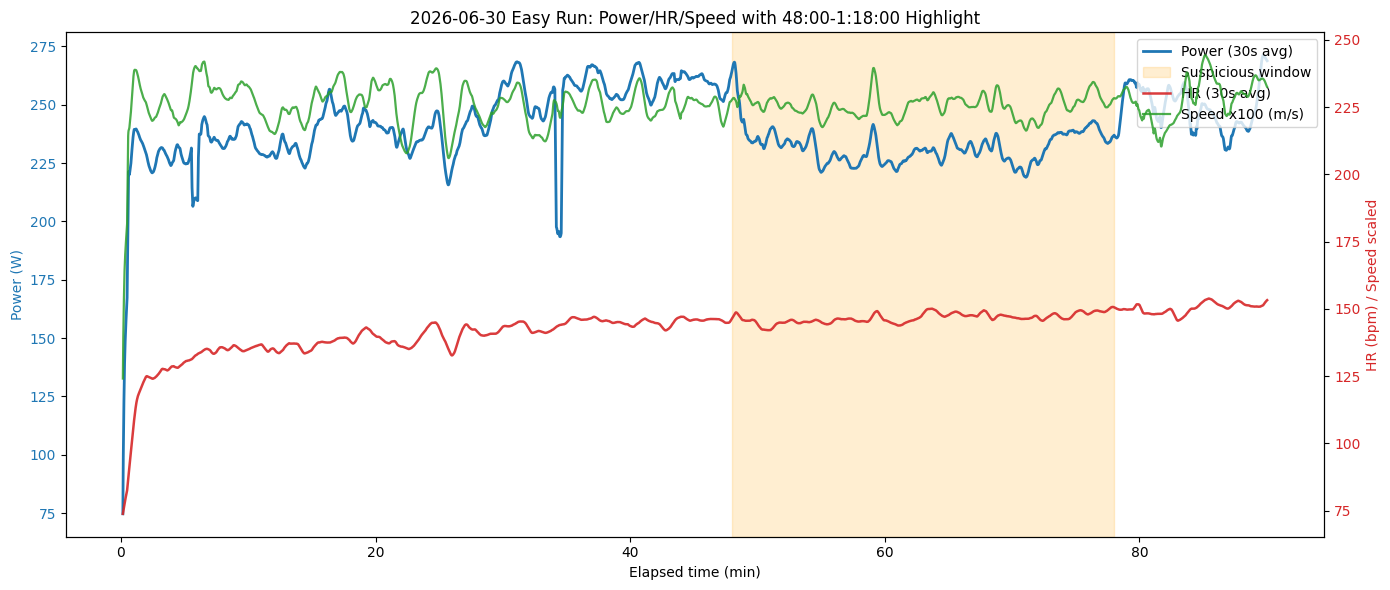

In [4]:
# Visualization
plot_df = df.copy()
plot_df['power_30s'] = plot_df['power'].rolling(30, min_periods=10).mean()
plot_df['hr_30s'] = plot_df['heart_rate'].rolling(30, min_periods=10).mean()
plot_df['speed_30s'] = plot_df['speed'].rolling(30, min_periods=10).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
x_min = plot_df['elapsed_s'] / 60.0

ax1.plot(x_min, plot_df['power_30s'], label='Power (30s avg)', color='tab:blue', linewidth=2)
ax1.set_xlabel('Elapsed time (min)')
ax1.set_ylabel('Power (W)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axvspan(48, 78, color='orange', alpha=0.18, label='Suspicious window')

ax2 = ax1.twinx()
ax2.plot(x_min, plot_df['hr_30s'], label='HR (30s avg)', color='tab:red', linewidth=1.8, alpha=0.9)
ax2.plot(x_min, plot_df['speed_30s'] * 100, label='Speed x100 (m/s)', color='tab:green', linewidth=1.6, alpha=0.85)
ax2.set_ylabel('HR (bpm) / Speed scaled', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
ax1.set_title('2026-06-30 Easy Run: Power/HR/Speed with 48:00-1:18:00 Highlight')
plt.tight_layout()
plt.show()

In [5]:
# Auto-diagnosis text
pw_drop_pre = compare.loc['power', 'window_vs_pre_%']
pw_drop_post = compare.loc['power', 'window_vs_post_%']
speed_delta_pre = compare.loc['speed', 'window_vs_pre_%']
hr_delta_pre = compare.loc['heart_rate', 'window_vs_pre_%']
cad_delta_pre = compare.loc['cadence', 'window_vs_pre_%']
stance_delta_pre = compare.loc['stance_time', 'window_vs_pre_%']
vr_delta_pre = compare.loc['vertical_ratio', 'window_vs_pre_%']
grade_win = compare.loc['grade_pct_30s', 'window_mean']

print('Diagnosis for 48:00-1:18:00')
print('-' * 40)
print(f'Power in window vs pre-window: {pw_drop_pre:+.1f}%')
print(f'Power in window vs post-window: {pw_drop_post:+.1f}%')
print(f'Speed change vs pre-window: {speed_delta_pre:+.1f}%')
print(f'HR change vs pre-window: {hr_delta_pre:+.1f}%')
print(f'Cadence change vs pre-window: {cad_delta_pre:+.1f}%')
print(f'Stance-time change vs pre-window: {stance_delta_pre:+.1f}%')
print(f'Vertical-ratio change vs pre-window: {vr_delta_pre:+.1f}%')
print(f'Average grade in window (30s smooth): {grade_win:+.3f}%')
print(f'Pause-like points in window: {int(win["is_pause_like"].sum())}')

print('Interpretation:')
if int(win['is_pause_like'].sum()) == 0 and abs(grade_win) < 0.2:
    print('1) Not a stop-go artifact and not a hill-driven drop.')
else:
    print('1) Includes either stoppage-like behavior or terrain contribution.')

if pw_drop_pre < -5 and abs(speed_delta_pre) < 2 and hr_delta_pre > 1:
    print('2) Power fell while speed stayed similar and HR drifted up -> likely fatigue/efficiency dip or intentional easing in running form.')
else:
    print('2) Pattern is mixed; check pacing intent and environment context.')

print('3) Sensor data quality is mostly stable, so this looks physiological/pacing-related rather than a major sensor failure.')

Diagnosis for 48:00-1:18:00
----------------------------------------
Power in window vs pre-window: -7.2%
Power in window vs post-window: -7.0%
Speed change vs pre-window: +0.1%
HR change vs pre-window: +2.7%
Cadence change vs pre-window: -0.6%
Stance-time change vs pre-window: +0.8%
Vertical-ratio change vs pre-window: +0.3%
Average grade in window (30s smooth): -0.068%
Pause-like points in window: 0
Interpretation:
1) Not a stop-go artifact and not a hill-driven drop.
2) Power fell while speed stayed similar and HR drifted up -> likely fatigue/efficiency dip or intentional easing in running form.
3) Sensor data quality is mostly stable, so this looks physiological/pacing-related rather than a major sensor failure.


## Cross-Run Comparison: Same 48:00-1:18:00 Segment

This section compares the same segment (48:00 to 1:18:00) across other recent easy runs that are close to 90 minutes.

It helps answer whether today's dip is unusual or part of your normal long-easy-run profile.

,run,timer_min,segment_points,power_mean,hr_mean,speed_mean,pace_mean,cadence_mean,power_per_hr,stance_mean,vr_mean,grade_mean,power_mean_vs_2026-06-30_%,hr_mean_vs_2026-06-30_%,speed_mean_vs_2026-06-30_%,power_per_hr_vs_2026-06-30_%,stance_mean_vs_2026-06-30_%,vr_mean_vs_2026-06-30_%
0,2026-05-21_thursday_easy,90.042,1801,227.536,155.863,2.275,7.328,167.478,1.460,281.069,9.796,-0.084,-1.795,6.282,0.860,-7.600,-1.436,-0.925
1,2026-05-23_saturday_easy,83.548,1751,236.699,156.895,2.399,6.998,166.668,1.509,278.393,9.562,-0.136,2.159,6.986,6.333,-4.512,-2.375,-3.284
2,2026-05-28_thursday_easy,90.118,1801,241.504,158.684,2.272,7.342,167.202,1.522,282.002,9.806,0.066,4.233,8.206,0.696,-3.672,-1.109,-0.820
3,2026-06-04_thursday_easy,90.016,1801,238.508,147.837,2.263,7.370,167.258,1.613,282.076,9.820,-0.102,2.940,0.810,0.305,2.113,-1.083,-0.674
4,2026-06-16_tuesday_easy,90.077,1801,236.512,153.704,2.266,7.358,164.071,1.539,285.848,9.881,-0.049,2.079,4.810,0.460,-2.606,0.239,-0.062
5,2026-06-23_tuesday_easy,90.006,1801,235.886,148.542,2.275,7.331,164.834,1.588,284.714,9.850,-0.138,1.808,1.290,0.841,0.511,-0.158,-0.378
6,2026-06-30_tuesday_easy,90.028,1801,231.696,146.650,2.256,7.391,164.941,1.580,285.165,9.887,-0.068,0.000,0.000,0.000,0.000,0.000,0.000


Segment ranking (higher is better output/efficiency):


,run,power_mean,power_per_hr,speed_mean,power_rank_high_to_low,efficiency_rank_high_to_low,speed_rank_high_to_low
2,2026-05-28_thursday_easy,241.504164,1.521918,2.271758,1,5,4
3,2026-06-04_thursday_easy,238.508051,1.613314,2.262933,2,1,6
1,2026-05-23_saturday_easy,236.698857,1.508646,2.398925,3,6,1
4,2026-06-16_tuesday_easy,236.512493,1.538752,2.266416,4,4,5
5,2026-06-23_tuesday_easy,235.885619,1.588007,2.275023,5,2,3
6,2026-06-30_tuesday_easy,231.696280,1.579931,2.256047,6,3,7
0,2026-05-21_thursday_easy,227.536369,1.459850,2.275450,7,7,2


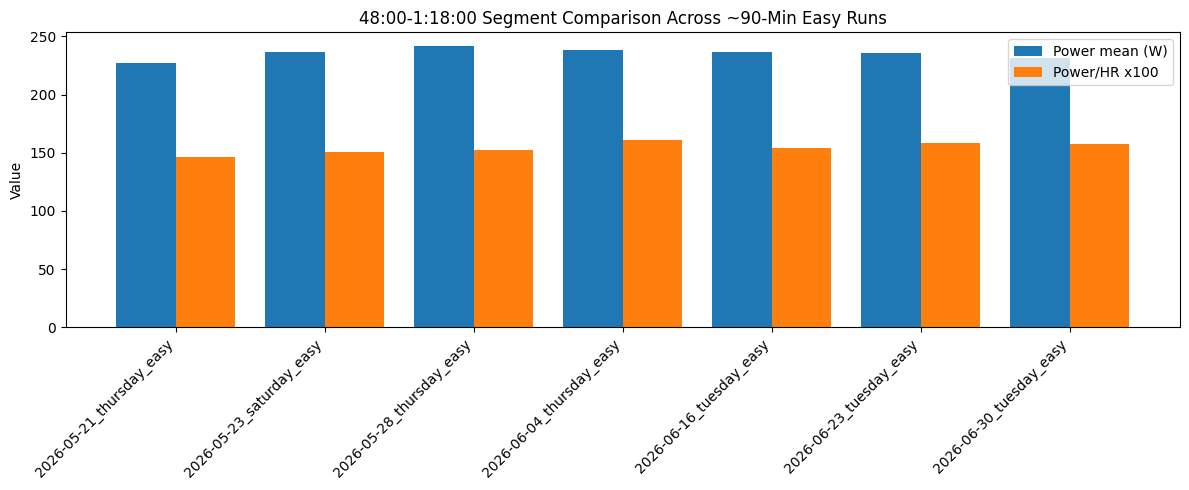

In [6]:
from pathlib import Path

base_dir = Path('../data/activities/easy/processed')
segment_start_s = 48 * 60
segment_end_s = 78 * 60

rows = []

for run_dir in sorted(base_dir.iterdir()):
    if not run_dir.is_dir():
        continue

    rec_path = run_dir / 'record.csv'
    ses_path = run_dir / 'session.csv'
    if not rec_path.exists() or not ses_path.exists():
        continue

    # Use session duration to keep comparable long easy runs (~90 min)
    try:
        ses = pd.read_csv(ses_path)
        if 'total_timer_time' not in ses.columns:
            continue
        timer_s = float(pd.to_numeric(ses['total_timer_time'], errors='coerce').iloc[0])
    except Exception:
        continue

    if np.isnan(timer_s):
        continue

    if not (80 * 60 <= timer_s <= 100 * 60):
        continue

    try:
        r = pd.read_csv(rec_path)
        r['timestamp'] = pd.to_datetime(r['timestamp'], utc=True)
        r = r.sort_values('timestamp').reset_index(drop=True)
        r['elapsed_s'] = (r['timestamp'] - r['timestamp'].iloc[0]).dt.total_seconds()

        for c in ['power', 'heart_rate', 'cadence', 'speed', 'step_length', 'stance_time', 'vertical_ratio', 'altitude', 'distance']:
            if c in r.columns:
                r[c] = pd.to_numeric(r[c], errors='coerce')

        r['pace_min_per_km'] = 1000 / (r['speed'].replace(0, np.nan) * 60)
        r['grade_pct_raw'] = (r['altitude'].diff() / r['distance'].diff().replace(0, np.nan)) * 100
        r['grade_pct_30s'] = r['grade_pct_raw'].rolling(30, min_periods=10).mean().clip(-10, 10)

        seg = r[(r['elapsed_s'] >= segment_start_s) & (r['elapsed_s'] <= segment_end_s)].copy()
        if len(seg) < 1200:
            continue

        rows.append({
            'run': run_dir.name,
            'timer_min': timer_s / 60,
            'segment_points': int(len(seg)),
            'power_mean': float(seg['power'].mean()),
            'hr_mean': float(seg['heart_rate'].mean()),
            'speed_mean': float(seg['speed'].mean()),
            'pace_mean': float(seg['pace_min_per_km'].mean()),
            'cadence_mean': float(seg['cadence'].mean()),
            'step_len_mean': float(seg['step_length'].mean()),
            'stance_mean': float(seg['stance_time'].mean()),
            'vr_mean': float(seg['vertical_ratio'].mean()),
            'grade_mean': float(seg['grade_pct_30s'].mean()),
            'power_per_hr': float(seg['power'].mean() / seg['heart_rate'].mean()),
        })
    except Exception:
        continue

cmp = pd.DataFrame(rows).sort_values('run').reset_index(drop=True)

if cmp.empty:
    print('No comparable ~90-minute runs were found with complete segment data.')
else:
    target_run = '2026-06-30_tuesday_easy'
    if target_run in set(cmp['run']):
        target_vals = cmp.loc[cmp['run'] == target_run].iloc[0]
        for col in ['power_mean', 'hr_mean', 'speed_mean', 'power_per_hr', 'stance_mean', 'vr_mean']:
            cmp[f'{col}_vs_2026-06-30_%'] = (cmp[col] / target_vals[col] - 1) * 100

    display_cols = [
        'run', 'timer_min', 'segment_points',
        'power_mean', 'hr_mean', 'speed_mean', 'pace_mean',
        'cadence_mean', 'power_per_hr', 'stance_mean', 'vr_mean', 'grade_mean'
    ]
    extra_cols = [c for c in cmp.columns if c.endswith('_vs_2026-06-30_%')]
    display(cmp[display_cols + extra_cols].round(3))

    # Quick ranking to see whether today's segment is unusually low
    rank = cmp[['run', 'power_mean', 'power_per_hr', 'speed_mean']].copy()
    rank['power_rank_high_to_low'] = rank['power_mean'].rank(ascending=False, method='min').astype(int)
    rank['efficiency_rank_high_to_low'] = rank['power_per_hr'].rank(ascending=False, method='min').astype(int)
    rank['speed_rank_high_to_low'] = rank['speed_mean'].rank(ascending=False, method='min').astype(int)
    print('Segment ranking (higher is better output/efficiency):')
    display(rank.sort_values('power_rank_high_to_low'))

    plt.figure(figsize=(12, 5))
    x = np.arange(len(cmp))
    plt.bar(x - 0.2, cmp['power_mean'], width=0.4, label='Power mean (W)')
    plt.bar(x + 0.2, cmp['power_per_hr'] * 100, width=0.4, label='Power/HR x100')
    plt.xticks(x, cmp['run'], rotation=45, ha='right')
    plt.ylabel('Value')
    plt.title('48:00-1:18:00 Segment Comparison Across ~90-Min Easy Runs')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Auto-Generated Comparison Conclusion

This cell generates a concise text interpretation from the cross-run segment comparison table.

In [7]:
target_run = '2026-06-30_tuesday_easy'

if 'cmp' not in globals() or cmp is None or len(cmp) == 0:
    print('Run the comparison cell above first to build the table.')
else:
    required_cols = {'run', 'power_mean', 'power_per_hr', 'speed_mean', 'hr_mean'}
    if not required_cols.issubset(set(cmp.columns)):
        print('Comparison table is missing required columns. Re-run the comparison cell above.')
    elif target_run not in set(cmp['run']):
        print(f'Target run {target_run} is not present in comparison table.')
    else:
        t = cmp.loc[cmp['run'] == target_run].iloc[0]
        others = cmp.loc[cmp['run'] != target_run].copy()

        # Percent differences versus peer median
        peer_med_power = float(others['power_mean'].median())
        peer_med_pwhr = float(others['power_per_hr'].median())
        peer_med_speed = float(others['speed_mean'].median())
        peer_med_hr = float(others['hr_mean'].median())

        d_power = (float(t['power_mean']) / peer_med_power - 1) * 100
        d_pwhr = (float(t['power_per_hr']) / peer_med_pwhr - 1) * 100
        d_speed = (float(t['speed_mean']) / peer_med_speed - 1) * 100
        d_hr = (float(t['hr_mean']) / peer_med_hr - 1) * 100

        # Ranks (1 = best)
        power_rank = int(cmp['power_mean'].rank(ascending=False, method='min')[cmp['run'] == target_run].iloc[0])
        pwhr_rank = int(cmp['power_per_hr'].rank(ascending=False, method='min')[cmp['run'] == target_run].iloc[0])
        speed_rank = int(cmp['speed_mean'].rank(ascending=False, method='min')[cmp['run'] == target_run].iloc[0])
        n_runs = int(len(cmp))

        print('Auto conclusion for 48:00-1:18:00 segment')
        print('-' * 52)
        print(f'- Power rank: {power_rank}/{n_runs} (1 = highest)')
        print(f'- Efficiency rank (power/HR): {pwhr_rank}/{n_runs}')
        print(f'- Speed rank: {speed_rank}/{n_runs}')
        print(f'- Power vs peer median: {d_power:+.1f}%')
        print(f'- Power/HR vs peer median: {d_pwhr:+.1f}%')
        print(f'- Speed vs peer median: {d_speed:+.1f}%')
        print(f'- HR vs peer median: {d_hr:+.1f}%')

        print('\nInterpretation:')
        if d_power <= -2 and d_speed > -1.5 and d_pwhr >= -2:
            print('Power is below your typical peer median while speed is close and efficiency is not strongly impaired.')
            print('This fits a moderate output dip likely driven by pacing choice or transient fatigue/form changes, not a major failure signal.')
        elif d_power <= -2 and d_pwhr <= -2:
            print('Both power and efficiency are below peer median, suggesting stronger fatigue/economy strain in this segment.')
        else:
            print('This segment sits within your normal run-to-run variation for comparable long easy runs.')

Auto conclusion for 48:00-1:18:00 segment
----------------------------------------------------
- Power rank: 6/7 (1 = highest)
- Efficiency rank (power/HR): 3/7
- Speed rank: 7/7
- Power vs peer median: -2.1%
- Power/HR vs peer median: +3.2%
- Speed vs peer median: -0.8%
- HR vs peer median: -5.3%

Interpretation:
Power is below your typical peer median while speed is close and efficiency is not strongly impaired.
This fits a moderate output dip likely driven by pacing choice or transient fatigue/form changes, not a major failure signal.


## Practical Conclusion

For this run, the 48:00-1:18:00 power depression is most consistent with a **temporary efficiency drop (fatigue + form shift) or deliberate easing**, not with hard stops or climbing.

Suggested follow-up checks in future easy runs:
- Add lap markers every 15 minutes to match perceived effort against power drift.
- Compare wind exposure and route direction in this segment.
- Track cadence-step-length product and stance time together; if power drops with stable pace, this often reflects form/economy drift.